In [1]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

In [2]:
spambase = pd.read_csv("spambase.data", header = None)
spambase.head()

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [3]:
print(spambase.shape)

(4601, 58)


## Problem 1: Logistic regression

In [4]:
X = spambase.iloc[:, :-1]
y = spambase.iloc[:, -1]

In [5]:
print(X.shape)
print(y.shape)
print(y.value_counts())

(4601, 57)
(4601,)
57
0    2788
1    1813
Name: count, dtype: int64


In [6]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.25, 
    random_state = 42
)

In [7]:
print(X_train.shape)
print(X_test.shape)

(3450, 57)
(1151, 57)


In [8]:
model = LogisticRegression(max_iter = 10000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [9]:
y_pred = model.predict(X_test)

### 1a - Confusion matrix

In [10]:
confusion_m = confusion_matrix(y_test, y_pred)
print(confusion_m)

[[651  25]
 [ 55 420]]


### 1b - Accuracy, Error

In [11]:
accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy 
print("Accuracy:", accuracy)
print("Error:", error)

Accuracy: 0.9304952215464813
Error: 0.06950477845351866


### 1c - Precision, Recall, F1 score

In [12]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9438202247191011
Recall: 0.8842105263157894
F1 Score: 0.9130434782608695


### 2

In [13]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

In [14]:
coef_sorted = coef_df.sort_values(by = "Coefficient", ascending = False)
print(coef_sorted)

    Feature  Coefficient
52       52     3.472774
22       22     2.140552
6         6     2.110429
14       14     1.503627
53       53     1.158177
15       15     1.011050
35       35     0.976607
19       19     0.905272
16       16     0.892491
3         3     0.753482
5         5     0.655042
4         4     0.633717
8         8     0.606605
7         7     0.497044
23       23     0.369488
27       27     0.339735
20       20     0.240795
21       21     0.235278
33       33     0.233894
51       51     0.233581
2         2     0.143411
31       31     0.119134
18       18     0.097390
13       13     0.090516
17       17     0.087818
9         9     0.078599
12       12     0.010730
55       55     0.006499
56       56     0.000922
54       54    -0.011131
39       39    -0.056493
36       36    -0.066364
11       11    -0.094130
1         1    -0.130202
30       30    -0.174122
49       49    -0.196907
0         0    -0.244349
50       50    -0.341208
10       10    -0.369117


### 3 

In [15]:
y_prob = model.predict_proba(X_test)[:,1]

In [16]:
T1 = 0.25
y_pred_thresh1 = (y_prob >= T1).astype(int)

accuracy = accuracy_score(y_test, y_pred_thresh1)
precision = precision_score(y_test, y_pred_thresh1)
recall = recall_score(y_test, y_pred_thresh1)

print("Threshold:", T1)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Threshold: 0.25
Accuracy: 0.9079061685490878
Precision: 0.8397790055248618
Recall: 0.96


In [17]:
T2 = 0.5
y_pred_thresh2 = (y_prob >= T2).astype(int)

accuracy = accuracy_score(y_test, y_pred_thresh2)
precision = precision_score(y_test, y_pred_thresh2)
recall = recall_score(y_test, y_pred_thresh2)

print("Threshold:", T2)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Threshold: 0.5
Accuracy: 0.9304952215464813
Precision: 0.9438202247191011
Recall: 0.8842105263157894


In [18]:
T3 = 0.75
y_pred_thresh3 = (y_prob >= T3).astype(int)

accuracy = accuracy_score(y_test, y_pred_thresh3)
precision = precision_score(y_test, y_pred_thresh3)
recall = recall_score(y_test, y_pred_thresh3)

print("Threshold:", T3)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Threshold: 0.75
Accuracy: 0.8861859252823632
Precision: 0.9574468085106383
Recall: 0.7578947368421053


In [19]:
T4 = 0.9
y_pred_thresh4 = (y_prob >= T4).astype(int)

accuracy = accuracy_score(y_test, y_pred_thresh4)
precision = precision_score(y_test, y_pred_thresh4)
recall = recall_score(y_test, y_pred_thresh4)

print("Threshold:", T4)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Threshold: 0.9
Accuracy: 0.8236316246741964
Precision: 0.9722222222222222
Recall: 0.5894736842105263


## Problem 2

In [20]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [21]:
def gradient_descent_logistic(X, y, alpha, iterations):
    N, d = X.shape
    theta = np.zeros(d)
    
    for i in range(iterations):
        predictions = sigmoid(X @ theta)
        gradient = (1/N) * X.T @ (predictions - y)
        theta = theta - alpha * gradient
    
    return theta

In [22]:
X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)

In [24]:
X_train_gd = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_gd = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

In [25]:
def cross_entropy_loss(X, y, theta):
    N = len(y)
    p = sigmoid(X @ theta)

    p = np.clip(p, 1e-15, 1 - 1e-15)

    loss = -(1/N) * np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
    return loss

In [26]:
alphas = [0.001, 0.01, 0.1]

for alpha in alphas:
    theta_10 = gradient_descent_logistic(X_train_gd, y_train_np, alpha, 10)
    theta_50 = gradient_descent_logistic(X_train_gd, y_train_np, alpha, 50)
    theta_100 = gradient_descent_logistic(X_train_gd, y_train_np, alpha, 100)
    
    loss_10 = cross_entropy_loss(X_train_gd, y_train_np, theta_10)
    loss_50 = cross_entropy_loss(X_train_gd, y_train_np, theta_50)
    loss_100 = cross_entropy_loss(X_train_gd, y_train_np, theta_100)

    y_train_prob = sigmoid(X_train_gd @ theta_100)
    y_train_pred = (y_train_prob >= 0.5).astype(int)

    train_accuracy = accuracy_score(y_train_np, y_train_pred)
    train_precision = precision_score(y_train_np, y_train_pred)
    train_recall = recall_score(y_train_np, y_train_pred)
    train_f1 = f1_score(y_train_np, y_train_pred)

    y_test_prob = sigmoid(X_test_gd @ theta_100)
    y_test_pred = (y_test_prob >= 0.5).astype(int)

    test_accuracy = accuracy_score(y_test_np, y_test_pred)
    test_precision = precision_score(y_test_np, y_test_pred)
    test_recall = recall_score(y_test_np, y_test_pred)
    test_f1 = f1_score(y_test_np, y_test_pred)

    print("Learning Rate:", alpha)
    print("Loss @10:", loss_10)
    print("Loss @50:", loss_50)
    print("Loss @100:", loss_100)

    print("Training:")
    print("Accuracy:", train_accuracy)
    print("Precision:", train_precision)
    print("Recall:", train_recall)
    print("F1:", train_f1)

    print("Testing:")
    print("Accuracy:", test_accuracy)
    print("Precision:", test_precision)
    print("Recall:", test_recall)
    print("F1:", test_f1)

    print()

Learning Rate: 0.001
Loss @10: 0.6885826014521534
Loss @50: 0.671211570607833
Loss @100: 0.6513329933914995
Training:
Accuracy: 0.8959420289855072
Precision: 0.8607221812822402
Recall: 0.8729446935724963
F1: 0.8667903525046382
Testing:
Accuracy: 0.8992180712423979
Precision: 0.881104033970276
Recall: 0.8736842105263158
F1: 0.8773784355179705

Learning Rate: 0.01
Loss @10: 0.6511669857747712
Loss @50: 0.5416199336398837
Loss @100: 0.46873406018219876
Training:
Accuracy: 0.8976811594202898
Precision: 0.8733889310083397
Recall: 0.8609865470852018
F1: 0.8671433948061724
Testing:
Accuracy: 0.9035621198957429
Precision: 0.9008810572687225
Recall: 0.8610526315789474
F1: 0.8805166846071044

Learning Rate: 0.1
Loss @10: 0.4653773277352569
Loss @50: 0.32412438774423286
Loss @100: 0.28907843871268446
Training:
Accuracy: 0.9078260869565218
Precision: 0.9112903225806451
Recall: 0.8445440956651719
F1: 0.8766485647788984
Testing:
Accuracy: 0.9061685490877498
Precision: 0.9237875288683602
Recall: 0.84

## Problem 3 

### Part 1 

In [27]:
k_values = [1, 3, 5, 7, 9]

In [28]:
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    y_val_pred = cross_val_predict(knn, X_train, y_train, cv=5)
    
    accuracy = accuracy_score(y_train, y_val_pred)
    error = 1 - accuracy
    precision = precision_score(y_train, y_val_pred)
    recall = recall_score(y_train, y_val_pred)
    
    print("k =", k)
    print("Accuracy:", accuracy)
    print("Error:", error)
    print("Precision:", precision)
    print("Recall:", recall)
    print()

k = 1
Accuracy: 0.8052173913043478
Error: 0.19478260869565223
Precision: 0.7518910741301059
Recall: 0.7428998505231689

k = 3
Accuracy: 0.7997101449275362
Error: 0.20028985507246377
Precision: 0.7482732156561781
Recall: 0.7286995515695067

k = 5
Accuracy: 0.792463768115942
Error: 0.207536231884058
Precision: 0.7414596273291926
Recall: 0.7137518684603886

k = 7
Accuracy: 0.7869565217391304
Error: 0.21304347826086956
Precision: 0.7328185328185328
Recall: 0.7092675635276532

k = 9
Accuracy: 0.7866666666666666
Error: 0.21333333333333337
Precision: 0.7315384615384616
Recall: 0.7107623318385651



### Part 2

In [29]:
def get_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    error = 1 - accuracy
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    return accuracy, error, precision, recall

In [30]:
log_train_pred = model.predict(X_train)
log_test_pred = model.predict(X_test)

In [31]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

lda_train_pred = lda.predict(X_train)
lda_test_pred = lda.predict(X_test)

In [32]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

knn_train_pred = knn.predict(X_train)
knn_test_pred = knn.predict(X_test)

In [33]:
def print_metrics(name, y_train, train_pred, y_test, test_pred):
    train_metrics = get_metrics(y_train, train_pred)
    test_metrics = get_metrics(y_test, test_pred)

    print(f"\n{name}")
    print("Training  - Accuracy: {:.4f}, Error: {:.4f}, Precision: {:.4f}, Recall: {:.4f}".format(*train_metrics))
    print("Testing   - Accuracy: {:.4f}, Error: {:.4f}, Precision: {:.4f}, Recall: {:.4f}".format(*test_metrics))

print_metrics("Logistic Regression", y_train, log_train_pred, y_test, log_test_pred)
print_metrics("LDA", y_train, lda_train_pred, y_test, lda_test_pred)
print_metrics("kNN (k=1)", y_train, knn_train_pred, y_test, knn_test_pred)


Logistic Regression
Training  - Accuracy: 0.9290, Error: 0.0710, Precision: 0.9266, Recall: 0.8871
Testing   - Accuracy: 0.9305, Error: 0.0695, Precision: 0.9438, Recall: 0.8842

LDA
Training  - Accuracy: 0.8867, Error: 0.1133, Precision: 0.9157, Recall: 0.7795
Testing   - Accuracy: 0.8853, Error: 0.1147, Precision: 0.9298, Recall: 0.7811

kNN (k=1)
Training  - Accuracy: 0.9994, Error: 0.0006, Precision: 0.9993, Recall: 0.9993
Testing   - Accuracy: 0.7993, Error: 0.2007, Precision: 0.7574, Recall: 0.7558


### Part 3

In [34]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.9745032700093429


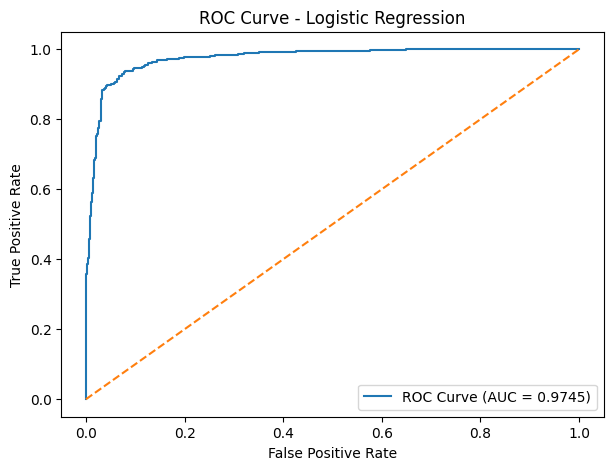

In [35]:
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

## Part 4

In [36]:
y_prob = model.predict_proba(X_test)[:,1]

thresholds = np.arange(0, 1.01, 0.1)

manual_fpr = []
manual_tpr = []

for T in thresholds: 
    y_pred_manual = (y_prob >= T).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_manual).ravel()

    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)

    manual_tpr.append(tpr)
    manual_fpr.append(fpr)

    print(f"Threshold = {T:.1f} | FPR = {fpr:.4f} | TPR = {tpr:.4f}")

Threshold = 0.0 | FPR = 1.0000 | TPR = 1.0000
Threshold = 0.1 | FPR = 0.3107 | TPR = 0.9853
Threshold = 0.2 | FPR = 0.1642 | TPR = 0.9726
Threshold = 0.3 | FPR = 0.0947 | TPR = 0.9432
Threshold = 0.4 | FPR = 0.0666 | TPR = 0.9221
Threshold = 0.5 | FPR = 0.0370 | TPR = 0.8842
Threshold = 0.6 | FPR = 0.0311 | TPR = 0.8274
Threshold = 0.7 | FPR = 0.0266 | TPR = 0.7874
Threshold = 0.8 | FPR = 0.0207 | TPR = 0.7158
Threshold = 0.9 | FPR = 0.0118 | TPR = 0.5895
Threshold = 1.0 | FPR = 0.0000 | TPR = 0.0000


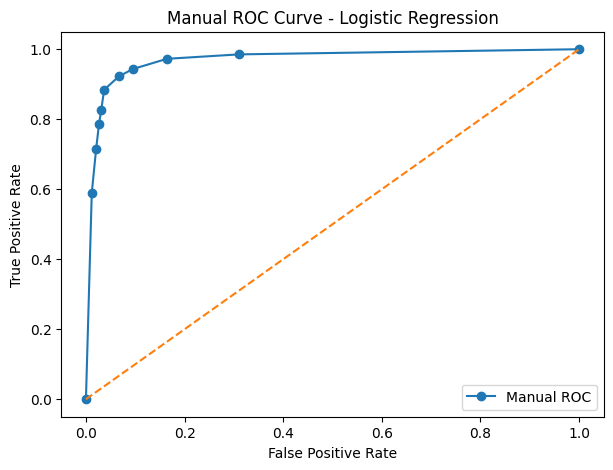

In [37]:
plt.figure(figsize=(7,5))
plt.plot(manual_fpr[::-1], manual_tpr[::-1], marker='o', label="Manual ROC")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual ROC Curve - Logistic Regression")
plt.legend()
plt.show()

## Problem 4

### Part 1

In [38]:
def manual_k_fold_cv(model_type, X, y, k):
    # convert pandas objects to numpy arrays
    X = np.array(X)
    y = np.array(y)

    n = len(X)

    indices = np.arange(n)
    np.random.seed(42)
    np.random.shuffle(indices)

    X_shuffled = X[indices]
    y_shuffled = y[indices]

    X_folds = np.array_split(X_shuffled, k)
    y_folds = np.array_split(y_shuffled, k)

    errors = []

    for i in range(k):
        X_val = X_folds[i]
        y_val = y_folds[i]

        X_train = np.concatenate([X_folds[j] for j in range(k) if j != i], axis=0)
        y_train = np.concatenate([y_folds[j] for j in range(k) if j != i], axis=0)

        if model_type == "logistic":
            model = LogisticRegression(max_iter=10000)
        elif model_type == "lda":
            model = LinearDiscriminantAnalysis()
        else:
            raise ValueError("model_type must be 'logistic' or 'lda'")

        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)

        error = 1 - accuracy_score(y_val, y_val_pred)
        errors.append(error)

    avg_error = np.mean(errors)
    return avg_error

### Part 2

In [39]:
for k in [5, 10]:
    log_error = manual_k_fold_cv("logistic", X, y, k)
    lda_error = manual_k_fold_cv("lda", X, y, k)

    print(f"k = {k}")
    print(f"Logistic Regression Average Validation Error: {log_error:.4f}")
    print(f"LDA Average Validation Error: {lda_error:.4f}")
    print()

k = 5
Logistic Regression Average Validation Error: 0.0722
LDA Average Validation Error: 0.1126

k = 10
Logistic Regression Average Validation Error: 0.0702
LDA Average Validation Error: 0.1128

